# LSTM Improvement Experiments
**CMPE 401 — Instructor-defined Project 2**

This notebook implements three controlled modifications to the baseline LSTM weather forecasting model.
Each experiment changes exactly one variable so results are directly comparable.

| # | Modification | Variable Changed |
|---|---|---|
| 1 | Dropout regularization | dropout rate on LSTM output |
| 2 | Stacked LSTM layers | Single to Two LSTM layers |
| 3 | Input sequence length | past window (360 / 720 / 1440 steps) |

**How to run:** Execute all cells top-to-bottom. Each experiment section is self-contained.
Results are collected into a summary table at the end.

---
## 0. Setup — Imports & Shared Utilities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
from zipfile import ZipFile

print(f"Keras version: {keras.__version__}")

Keras version: 3.13.2


---
## 1. Data Loading & Preprocessing

We load the **Jena Climate dataset** (2009–2016, 10-minute intervals) and select the same
7 features used in the baseline. Normalization uses only training-split statistics to
avoid data leakage into validation.

In [2]:
# --- Download & load ---
uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
ZipFile(zip_path).extractall()

df = pd.read_csv("jena_climate_2009_2016.csv")
print(f"Dataset shape: {df.shape}")
df.head(3)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6


In [3]:
# --- Feature selection (same 7 as baseline) ---
feature_keys = [
    "p (mbar)", "T (degC)", "VPmax (mbar)", "VPdef (mbar)",
    "sh (g/kg)", "rho (g/m**3)", "wv (m/s)",
]
titles = ["Pressure", "Temperature", "Sat. vapor pressure",
          "Vapor pressure deficit", "Specific humidity",
          "Airtight", "Wind speed"]

# --- Train/val split fraction ---
split_fraction = 0.715
train_split = int(split_fraction * len(df))

# --- Normalization (fit on train only) ---
def normalize(data, train_split):
    mean = data[:train_split].mean(axis=0)
    std  = data[:train_split].std(axis=0)
    return (data - mean) / std

features_raw = df[feature_keys].values
features_norm = normalize(features_raw, train_split)
features_df = pd.DataFrame(features_norm, columns=feature_keys)

print(f"Train samples : {train_split:,}")
print(f"Val   samples : {len(df) - train_split:,}")

Train samples : 300,693
Val   samples : 119,858


In [4]:
# -----------------------------------------------------------------------
# build_datasets(past)
# Creates train and validation tf.data.Datasets for a given lookback window.
#
# Parameters
# ----------
# past  : int  — number of 10-min timesteps to look back
#                (e.g. 720 = 120 hours = 5 days)
# Returns
# -------
# dataset_train, dataset_val, sequence_length
# -----------------------------------------------------------------------
def build_datasets(past, future=72, step=6, batch_size=256):
    """
    Parameters
    ----------
    past        : lookback window in 10-min steps (experiment variable)
    future      : how far ahead to predict (72 steps = 12 hours)
    step        : sub-sampling rate (6 steps = 1 sample/hour)
    batch_size  : mini-batch size
    """
    sequence_length = int(past / step)   # number of hourly observations fed to LSTM

    # --- Training set ---
    start_train = past + future
    end_train   = start_train + train_split

    x_train = features_df.loc[0 : train_split - 1].values
    y_train = features_df.iloc[start_train : end_train][["T (degC)"]]   # col 1 = Temperature

    dataset_train = keras.preprocessing.timeseries_dataset_from_array(
        x_train, y_train,
        sequence_length=sequence_length,
        sampling_rate=step,
        batch_size=batch_size,
    )

    # --- Validation set ---
    val_data    = features_df.loc[train_split:]
    x_end       = len(val_data) - past - future
    label_start = train_split + past + future

    x_val = val_data.iloc[:x_end].values
    y_val = features_df.iloc[label_start:][["T (degC)"]]

    dataset_val = keras.preprocessing.timeseries_dataset_from_array(
        x_val, y_val,
        sequence_length=sequence_length,
        sampling_rate=step,
        batch_size=batch_size,
    )

    return dataset_train, dataset_val, sequence_length

print("build_datasets() helper defined.")

build_datasets() helper defined.


In [5]:
# -----------------------------------------------------------------------
# train_and_evaluate(model, dataset_train, dataset_val, label)
# Shared training loop used by every experiment.
# Returns the best validation loss achieved.
# -----------------------------------------------------------------------
def train_and_evaluate(model, dataset_train, dataset_val, label,
                       learning_rate=0.001, epochs=10):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=f"best_{label}.weights.h5",
            monitor="val_loss",
            save_weights_only=True,
            save_best_only=True,
            verbose=0,
        ),
    ]

    history = model.fit(
        dataset_train,
        epochs=epochs,
        validation_data=dataset_val,
        callbacks=callbacks,
        verbose=1,
    )

    best_val_loss = min(history.history["val_loss"])
    print(f"\n[{label}] Best val_loss = {best_val_loss:.6f}")
    return history, best_val_loss


# -----------------------------------------------------------------------
# plot_loss(history, title)
# -----------------------------------------------------------------------
def plot_loss(history, title):
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs   = range(1, len(loss) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, loss,     "b", label="Train loss")
    plt.plot(epochs, val_loss, "r", label="Val loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("train_and_evaluate() and plot_loss() helpers defined.")

train_and_evaluate() and plot_loss() helpers defined.


---
## 2. Baseline — Single LSTM (No Dropout, past=720)

Reproduces the exact architecture from the Keras example so we have a reference
val_loss to compare every modification against.

In [6]:
PAST_BASELINE = 720   # 120 hours lookback (baseline default)

ds_train, ds_val, seq_len = build_datasets(past=PAST_BASELINE)

# Inspect one batch to confirm shapes
for x_batch, y_batch in ds_train.take(1):
    print(f"Input shape : {x_batch.numpy().shape}   (batch, seq_len, features)")
    print(f"Target shape: {y_batch.numpy().shape}   (batch, 1)")

Input shape : (256, 120, 7)   (batch, seq_len, features)
Target shape: (256, 1)   (batch, 1)


In [7]:
# --- Baseline model ---
def build_baseline(input_shape):
    inputs  = keras.layers.Input(shape=input_shape)
    x       = keras.layers.LSTM(32)(inputs)
    outputs = keras.layers.Dense(1)(x)
    return keras.Model(inputs, outputs)

model_baseline = build_baseline((seq_len, 7))
model_baseline.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 190s 161ms/step - loss: 0.2040 - val_loss: 0.1427
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 183s 156ms/step - loss: 0.1225 - val_loss: 0.1413
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 180s 153ms/step - loss: 0.1134 - val_loss: 0.1404
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 188s 161ms/step - loss: 0.1094 - val_loss: 0.1421
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 184s 157ms/step - loss: 0.1066 - val_loss: 0.1402
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 181s 154ms/step - loss: 0.1047 - val_loss: 0.1374
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 172s 147ms/step - loss: 0.1036 - val_loss: 0.1327
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 174s 148ms/step - loss: 0.1023 - val_loss: 0.1287
Epoch 9/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 173s 147ms/step - loss: 0.1009 - val_loss: 0.1248
Epoch 10/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 180s 154ms/step - loss: 0.0996 - val_loss: 0.1227

[baseline] Best val_loss = 0.122696


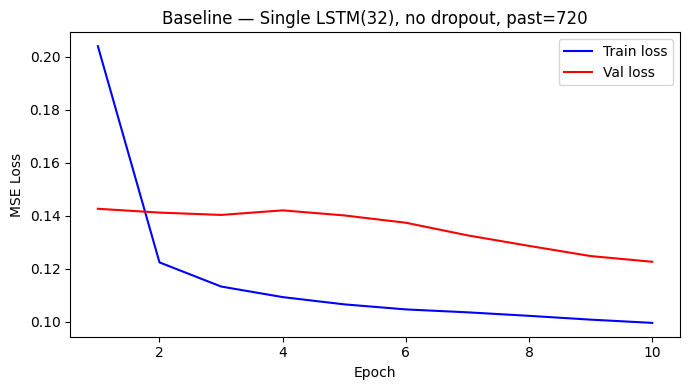

In [8]:
history_baseline, val_loss_baseline = train_and_evaluate(
    model_baseline, ds_train, ds_val, label="baseline"
)
plot_loss(history_baseline, "Baseline — Single LSTM(32), no dropout, past=720")


## 3. Experiment 1 — Dropout Regularization

Dropout randomly zeros activations during training, reducing overfitting by preventing
co-adaptation of neurons.


  Dropout rate = 0.1
Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 178s 150ms/step - loss: 0.2055 - val_loss: 0.1571
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 179s 153ms/step - loss: 0.1339 - val_loss: 0.1423
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 177s 151ms/step - loss: 0.1238 - val_loss: 0.1463
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 179s 152ms/step - loss: 0.1203 - val_loss: 0.1498
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 174s 148ms/step - loss: 0.1183 - val_loss: 0.1455
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 180s 154ms/step - loss: 0.1148 - val_loss: 0.1491
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 177s 151ms/step - loss: 0.1120 - val_loss: 0.1437

[dropout_0.1] Best val_loss = 0.142252


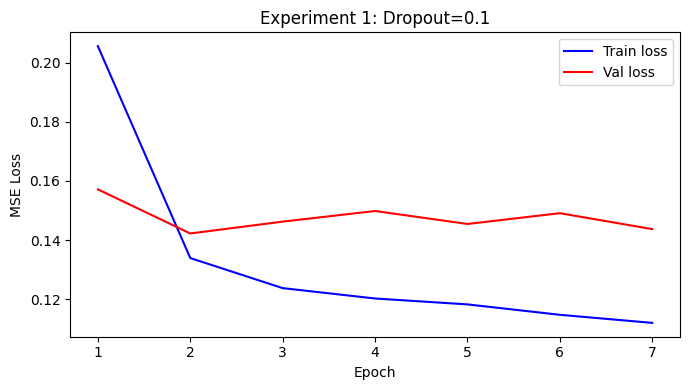


  Dropout rate = 0.2
Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 188s 159ms/step - loss: 0.2189 - val_loss: 0.1515
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 185s 158ms/step - loss: 0.1409 - val_loss: 0.1454
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 181s 155ms/step - loss: 0.1329 - val_loss: 0.1448
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 179s 153ms/step - loss: 0.1282 - val_loss: 0.1496
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 182s 155ms/step - loss: 0.1245 - val_loss: 0.1559
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 180s 153ms/step - loss: 0.1216 - val_loss: 0.1583
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 184s 157ms/step - loss: 0.1235 - val_loss: 0.1436
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 192s 164ms/step - loss: 0.1188 - val_loss: 0.1436
Epoch 9/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 183s 156ms/step - loss: 0.1174 - val_loss: 0.1416
Epoch 10/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 182s 155ms/step - loss: 0.1167 - val_loss: 0.1397

[dropout_0.2] Best val_loss = 0.139744


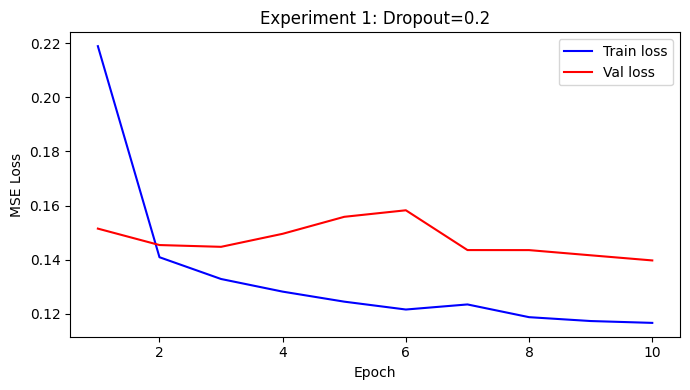


  Dropout rate = 0.3
Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 185s 156ms/step - loss: 0.2342 - val_loss: 0.1578
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 178s 152ms/step - loss: 0.1510 - val_loss: 0.1450
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 174s 148ms/step - loss: 0.1413 - val_loss: 0.1401
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 175s 150ms/step - loss: 0.1339 - val_loss: 0.1370
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 180s 154ms/step - loss: 0.1299 - val_loss: 0.1391
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 180s 153ms/step - loss: 0.1280 - val_loss: 0.1390
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 177s 151ms/step - loss: 0.1260 - val_loss: 0.1367
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 180s 154ms/step - loss: 0.1238 - val_loss: 0.1383
Epoch 9/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 179s 153ms/step - loss: 0.1219 - val_loss: 0.1410
Epoch 10/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 182s 156ms/step - loss: 0.1218 - val_loss: 0.1339

[dropout_0.3] Best val_loss = 0.133902


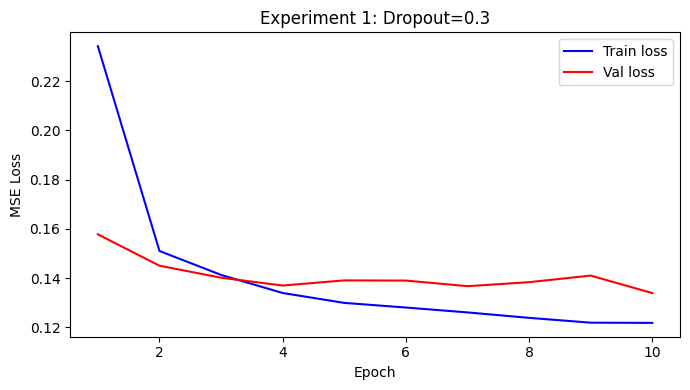


  Dropout rate = 0.5
Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 188s 158ms/step - loss: 0.2344 - val_loss: 0.1631
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 186s 158ms/step - loss: 0.1711 - val_loss: 0.1561
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 185s 158ms/step - loss: 0.1609 - val_loss: 0.1518
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 178s 152ms/step - loss: 0.1566 - val_loss: 0.1483
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 178s 152ms/step - loss: 0.1526 - val_loss: 0.1479
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 179s 153ms/step - loss: 0.1504 - val_loss: 0.1453
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 180s 154ms/step - loss: 0.1468 - val_loss: 0.1473
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 200s 153ms/step - loss: 0.1450 - val_loss: 0.1468
Epoch 9/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 175s 150ms/step - loss: 0.1460 - val_loss: 0.1377
Epoch 10/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 179s 153ms/step - loss: 0.1425 - val_loss: 0.1389

[dropout_0.5] Best val_loss = 0.137704


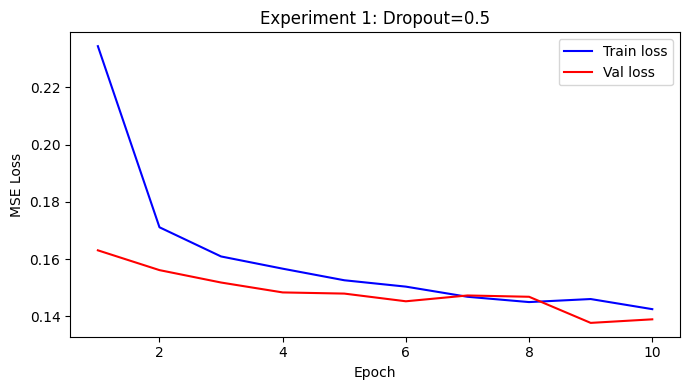

In [9]:
def build_with_dropout(input_shape, dropout_rate):
    """
    Single LSTM(32) followed by a Dropout layer before the Dense output.
    All other hyperparameters are identical to the baseline.
    """
    inputs  = keras.layers.Input(shape=input_shape)
    x       = keras.layers.LSTM(32)(inputs)
    x       = keras.layers.Dropout(dropout_rate)(x)   # <-- only change
    outputs = keras.layers.Dense(1)(x)
    return keras.Model(inputs, outputs)

dropout_rates = [0.1, 0.2, 0.3, 0.5]
results_dropout = {}   # {rate: best_val_loss}

ds_train_e1, ds_val_e1, seq_len_e1 = build_datasets(past=PAST_BASELINE)

for rate in dropout_rates:
    print(f"\n{'='*55}")
    print(f"  Dropout rate = {rate}")
    print(f"{'='*55}")
    model = build_with_dropout((seq_len_e1, 7), dropout_rate=rate)
    history, best_val = train_and_evaluate(
        model, ds_train_e1, ds_val_e1, label=f"dropout_{rate}"
    )
    plot_loss(history, f"Experiment 1: Dropout={rate}")
    results_dropout[rate] = best_val

In [10]:
# --- Experiment 1 Summary ---
print("\nExperiment 1 — Dropout Comparison")
print("-" * 38)
print(f"  Baseline (no dropout): {val_loss_baseline:.6f}")
for rate, loss in results_dropout.items():
    delta = loss - val_loss_baseline
    sign  = "+" if delta >= 0 else ""
    print(f"  Dropout {rate:<4}: {loss:.6f}  ({sign}{delta:.6f})")


Experiment 1 — Dropout Comparison
--------------------------------------
  Baseline (no dropout): 0.122696
  Dropout 0.1 : 0.142252  (+0.019557)
  Dropout 0.2 : 0.139744  (+0.017048)
  Dropout 0.3 : 0.133902  (+0.011206)
  Dropout 0.5 : 0.137704  (+0.015008)



## 4. Experiment 2 — Stacked LSTM Layers


A single LSTM learns one level of temporal abstraction. Stacking a second layer
allows the model to learn higher-order patterns — e.g. the first layer might encode
hourly fluctuations, the second encodes multi-day trends.

The first LSTM must use return_sequences=True so it outputs the full hidden-state sequence (batch, seq_len, units) that the second LSTM
can consume step-by-step


  Stacked LSTM: LSTM(32) → LSTM(32)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 120, 32)        │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,473 (52.63 KB)

 Trainable params: 13,473 (52.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 318s 269ms/step - loss: 0.1811 - val_loss: 0.1693
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 321s 274ms/step - loss: 0.1293 - val_loss: 0.1476
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 353s 301ms/step - loss: 0.1178 - val_loss: 0.1396
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 323s 276ms/step - loss: 0.1127 - val_loss: 0.1392
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 348s 297ms/step - loss: 0.1096 - val_loss: 0.1380
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 324s 276ms/step - loss: 0.1077 - val_loss: 0.1347
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 323s 276ms/step - loss: 0.1053 - val_loss: 0.1335
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 323s 276ms/step - loss: 0.1034 - val_loss: 0.1344
Epoch 9/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 327s 279ms/step - loss: 0.1021 - val_loss: 0.1325
Epoch 10/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 379s 276ms/step - loss: 0.1003 - val_loss: 0.1336

[stacked_32_32] Best val_loss = 0.132490


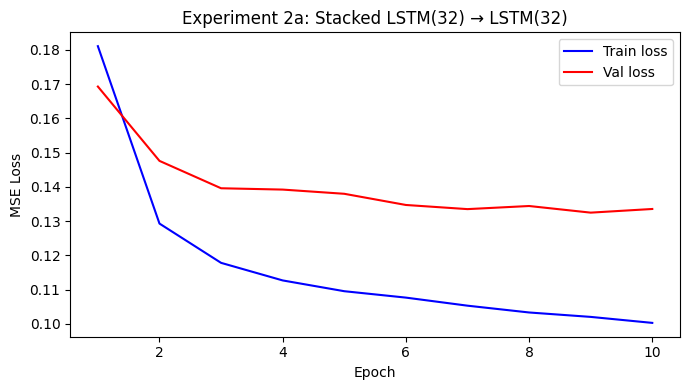


  Stacked LSTM: LSTM(64) → LSTM(32)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120, 64)        │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 576s 489ms/step - loss: 0.1737 - val_loss: 0.1698
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 590s 503ms/step - loss: 0.1291 - val_loss: 0.1604
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 579s 494ms/step - loss: 0.1184 - val_loss: 0.1655
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 569s 486ms/step - loss: 0.1151 - val_loss: 0.1554
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 578s 493ms/step - loss: 0.1121 - val_loss: 0.1519
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 573s 489ms/step - loss: 0.1101 - val_loss: 0.1459
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 566s 483ms/step - loss: 0.1063 - val_loss: 0.1448
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 564s 482ms/step - loss: 0.1048 - val_loss: 0.1387
Epoch 9/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 563s 480ms/step - loss: 0.1022 - val_loss: 0.1342
Epoch 10/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 567s 483ms/step - loss: 0.1005 - val_loss: 0.1333

[stacked_64_32] Best val_loss = 0.133303


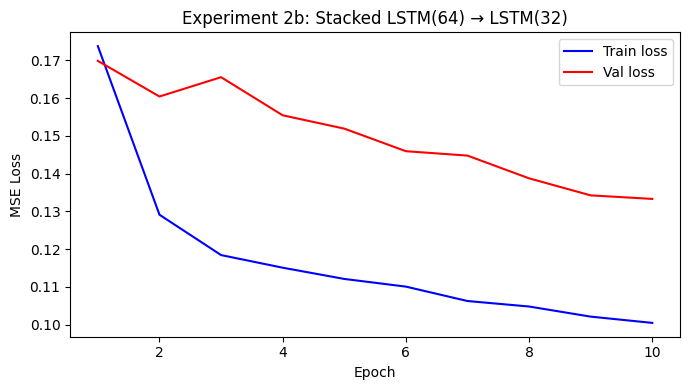

In [11]:
def build_stacked_lstm(input_shape, units_1=32, units_2=32, dropout_rate=0.0):
    """
    Two stacked LSTM layers.
    The first layer uses return_sequences=True to pass the full sequence
    to the second LSTM.
    """
    inputs = keras.layers.Input(shape=input_shape)
    # Layer 1: outputs full sequence so Layer 2 can attend to each step
    x = keras.layers.LSTM(units_1, return_sequences=True)(inputs)
    # Layer 2: outputs only the final hidden state
    x = keras.layers.LSTM(units_2)(x)
    if dropout_rate > 0:
        x = keras.layers.Dropout(dropout_rate)(x)
    outputs = keras.layers.Dense(1)(x)
    return keras.Model(inputs, outputs)


ds_train_e2, ds_val_e2, seq_len_e2 = build_datasets(past=PAST_BASELINE)

# --- 2a: Stacked LSTM, same total capacity as baseline (32 + 32 units) ---
print("\n" + "="*55)
print("  Stacked LSTM: LSTM(32) → LSTM(32)")
print("="*55)
model_stacked = build_stacked_lstm((seq_len_e2, 7), units_1=32, units_2=32)
model_stacked.summary()
history_stacked, val_loss_stacked = train_and_evaluate(
    model_stacked, ds_train_e2, ds_val_e2, label="stacked_32_32"
)
plot_loss(history_stacked, "Experiment 2a: Stacked LSTM(32) → LSTM(32)")

# --- 2b: Stacked LSTM with larger first layer ---
print("\n" + "="*55)
print("  Stacked LSTM: LSTM(64) → LSTM(32)")
print("="*55)
model_stacked_64 = build_stacked_lstm((seq_len_e2, 7), units_1=64, units_2=32)
model_stacked_64.summary()
history_stacked_64, val_loss_stacked_64 = train_and_evaluate(
    model_stacked_64, ds_train_e2, ds_val_e2, label="stacked_64_32"
)
plot_loss(history_stacked_64, "Experiment 2b: Stacked LSTM(64) → LSTM(32)")

In [12]:
# --- Experiment 2 Summary ---
print("\nExperiment 2 — Stacked LSTM Comparison")
print("-" * 42)
print(f"  Baseline  (single LSTM 32)    : {val_loss_baseline:.6f}")
print(f"  Stacked   LSTM(32) → LSTM(32) : {val_loss_stacked:.6f}")
print(f"  Stacked   LSTM(64) → LSTM(32) : {val_loss_stacked_64:.6f}")


Experiment 2 — Stacked LSTM Comparison
------------------------------------------
  Baseline  (single LSTM 32)    : 0.122696
  Stacked   LSTM(32) → LSTM(32) : 0.132490
  Stacked   LSTM(64) → LSTM(32) : 0.133303


## 5. Experiment 3 — Input Sequence Length

We vary how many timesteps of history the model sees.

| past value | Real-world window | sequence_length fed to LSTM |
|---|---|---|
| 360 | 60 hours (~2.5 days) | 60 steps |
| 720 | 120 hours (5 days) — baseline | 120 steps |
| 1440 | 240 hours (10 days) | 240 steps |

The optimal lookback depends on how far back in time patterns useful for 12-hour-ahead temperature prediction actually exist. Too short and the model misses multi-day cycles; too long and the model wastes capacity on distant, noisy history.


  past = 360 steps  (60 hours lookback)
  → sequence_length fed to LSTM: 60
Epoch 1/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 129s 108ms/step - loss: 0.2031 - val_loss: 0.1591
Epoch 2/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 126s 107ms/step - loss: 0.1252 - val_loss: 0.1401
Epoch 3/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 125s 106ms/step - loss: 0.1157 - val_loss: 0.1406
Epoch 4/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 131s 111ms/step - loss: 0.1135 - val_loss: 0.1373
Epoch 5/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 125s 106ms/step - loss: 0.1097 - val_loss: 0.1332
Epoch 6/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 124s 106ms/step - loss: 0.1076 - val_loss: 0.1296
Epoch 7/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 126s 107ms/step - loss: 0.1056 - val_loss: 0.1273
Epoch 8/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 127s 108ms/step - loss: 0.1037 - val_loss: 0.1245
Epoch 9/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 128s 109ms/step - loss: 0.1043 - val_loss: 0.1224
Epoch 10/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 124s 105ms/step - loss: 0.1008 - val_loss: 0.1218

[

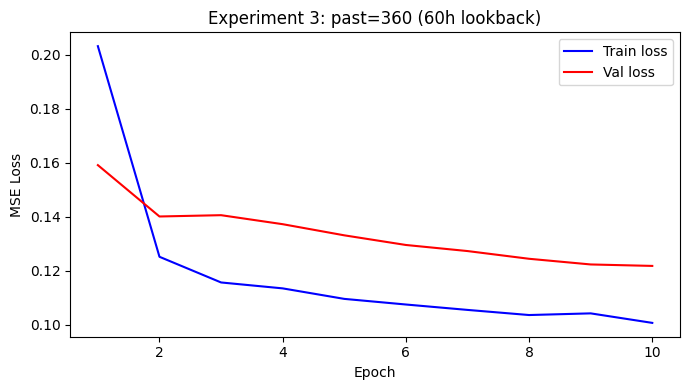


  past = 720 steps  (120 hours lookback)
  → sequence_length fed to LSTM: 120
Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 178s 150ms/step - loss: 0.1946 - val_loss: 0.1595
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 182s 155ms/step - loss: 0.1220 - val_loss: 0.1442
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 175s 150ms/step - loss: 0.1153 - val_loss: 0.1414
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 172s 147ms/step - loss: 0.1109 - val_loss: 0.1369
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 174s 148ms/step - loss: 0.1083 - val_loss: 0.1365
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 173s 148ms/step - loss: 0.1061 - val_loss: 0.1375
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 175s 149ms/step - loss: 0.1043 - val_loss: 0.1377
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 180s 153ms/step - loss: 0.1027 - val_loss: 0.1359
Epoch 9/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 177s 151ms/step - loss: 0.1012 - val_loss: 0.1335
Epoch 10/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 175s 149ms/step - loss: 0.0999 - val_loss: 0.1311


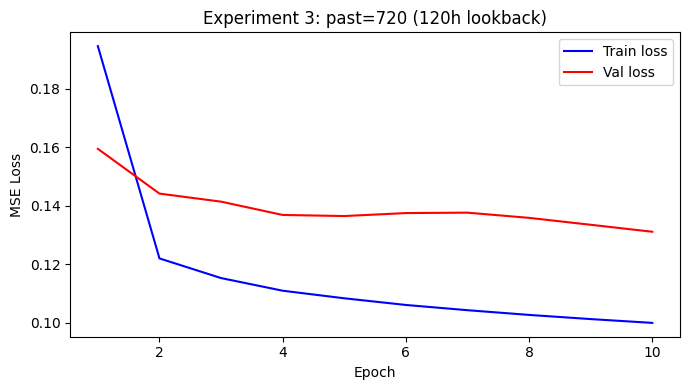


  past = 1440 steps  (240 hours lookback)
  → sequence_length fed to LSTM: 240
Epoch 1/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 283s 240ms/step - loss: 0.1956 - val_loss: 0.1476
Epoch 2/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 279s 238ms/step - loss: 0.1225 - val_loss: 0.1362
Epoch 3/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 279s 239ms/step - loss: 0.1139 - val_loss: 0.1378
Epoch 4/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 326s 243ms/step - loss: 0.1099 - val_loss: 0.1372
Epoch 5/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 281s 240ms/step - loss: 0.1073 - val_loss: 0.1359
Epoch 6/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 283s 242ms/step - loss: 0.1048 - val_loss: 0.1364
Epoch 7/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 285s 244ms/step - loss: 0.1031 - val_loss: 0.1355
Epoch 8/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 279s 239ms/step - loss: 0.1018 - val_loss: 0.1332
Epoch 9/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 281s 240ms/step - loss: 0.0995 - val_loss: 0.1343
Epoch 10/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 277s 237ms/step - loss: 0.0984 - val_loss: 0.1312

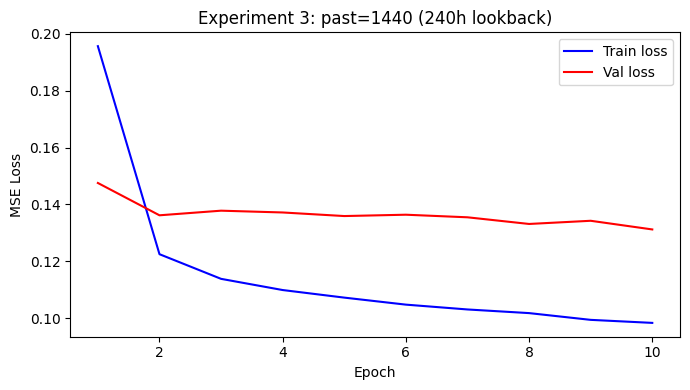

In [13]:
past_values = [360, 720, 1440]
results_seq = {}   # {past: best_val_loss}

for past in past_values:
    label = f"past_{past}"
    print(f"\n{'='*55}")
    print(f"  past = {past} steps  ({past // 6} hours lookback)")
    print(f"{'='*55}")

    ds_train_e3, ds_val_e3, seq_len_e3 = build_datasets(past=past)
    print(f"  → sequence_length fed to LSTM: {seq_len_e3}")

    # Same single-LSTM architecture as baseline; only the input length changes
    inputs  = keras.layers.Input(shape=(seq_len_e3, 7))
    x       = keras.layers.LSTM(32)(inputs)
    outputs = keras.layers.Dense(1)(x)
    model   = keras.Model(inputs, outputs)

    history, best_val = train_and_evaluate(
        model, ds_train_e3, ds_val_e3, label=label
    )
    plot_loss(history, f"Experiment 3: past={past} ({past // 6}h lookback)")
    results_seq[past] = best_val

In [14]:
# --- Experiment 3 Summary ---
print("\nExperiment 3 — Sequence Length Comparison")
print("-" * 44)
for past, loss in results_seq.items():
    marker = "  ← baseline" if past == 720 else ""
    print(f"  past={past:4d} ({past // 6:3d}h): {loss:.6f}{marker}")


Experiment 3 — Sequence Length Comparison
--------------------------------------------
  past= 360 ( 60h): 0.121850
  past= 720 (120h): 0.131121  ← baseline
  past=1440 (240h): 0.131232


---
## 6. Final Results Summary

Consolidates all experiment results into a single comparison table and saves it
to `results/lstm_improvements_results.csv` for the README benchmark.

In [ ]:
import os

rows = []

# Baseline
rows.append({
    "Experiment"        : "Baseline",
    "Description"       : "Single LSTM(32), no dropout, past=720",
    "Best Val Loss (MSE)": round(val_loss_baseline, 6),
    "vs Baseline"       : "—",
})

# Experiment 1 — Dropout
for rate, loss in results_dropout.items():
    delta = loss - val_loss_baseline
    rows.append({
        "Experiment"        : f"Exp 1: Dropout={rate}",
        "Description"       : f"Dropout({rate}) after LSTM output",
        "Best Val Loss (MSE)": round(loss, 6),
        "vs Baseline"       : f"{delta:+.6f}",
    })

# Experiment 2 — Stacked LSTM
for desc, loss in [("LSTM(32)→LSTM(32)", val_loss_stacked),
                   ("LSTM(64)→LSTM(32)", val_loss_stacked_64)]:
    delta = loss - val_loss_baseline
    rows.append({
        "Experiment"        : f"Exp 2: Stacked {desc}",
        "Description"       : f"Two stacked layers: {desc}",
        "Best Val Loss (MSE)": round(loss, 6),
        "vs Baseline"       : f"{delta:+.6f}",
    })

# Experiment 3 — Sequence length
for past, loss in results_seq.items():
    delta = loss - val_loss_baseline
    marker = " (baseline)" if past == 720 else ""
    rows.append({
        "Experiment"        : f"Exp 3: past={past}",
        "Description"       : f"{past} steps ({past // 6}h lookback){marker}",
        "Best Val Loss (MSE)": round(loss, 6),
        "vs Baseline"       : f"{delta:+.6f}" if past != 720 else "—",
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

# Save for README
os.makedirs("../results", exist_ok=True)
results_df.to_csv("../results/lstm_improvements_results.csv", index=False)
print("\nSaved to results/lstm_improvements_results.csv")

                      Experiment                           Description  Best Val Loss (MSE) vs Baseline
                        Baseline Single LSTM(32), no dropout, past=720             0.122696           —
              Exp 1: Dropout=0.1        Dropout(0.1) after LSTM output             0.142252   +0.019557
              Exp 1: Dropout=0.2        Dropout(0.2) after LSTM output             0.139744   +0.017048
              Exp 1: Dropout=0.3        Dropout(0.3) after LSTM output             0.133902   +0.011206
              Exp 1: Dropout=0.5        Dropout(0.5) after LSTM output             0.137704   +0.015008
Exp 2: Stacked LSTM(32)→LSTM(32) Two stacked layers: LSTM(32)→LSTM(32)             0.132490   +0.009794
Exp 2: Stacked LSTM(64)→LSTM(32) Two stacked layers: LSTM(64)→LSTM(32)             0.133303   +0.010607
                 Exp 3: past=360              360 steps (60h lookback)             0.121850   -0.000846
                 Exp 3: past=720  720 steps (120h lookback) (bas